Упражнение 26.1 Решить в целых числах с помощь пакета lpSolve применяя метод ветвей и границ интерактивно.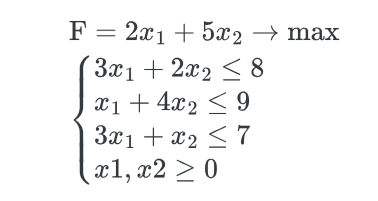

In [12]:
import numpy as np
from scipy.optimize import linprog

c = [-2, -5]

A = [
    [3, 2],
    [1, 4],
    [3, 1]
]

b = [8, 9, 7]

bounds_root = [(0, None), (0, None)]


In [13]:


res_root = linprog(c, A_ub=A, b_ub=b, bounds=bounds_root, method='highs')

print("=== Шаг 1: Корневой узел (непрерывное решение) ===")
print("Статус (0 означает успех):", res_root.status)
print(f"x1 = {res_root.x[0]:.2f}")
print(f"x2 = {res_root.x[1]:.2f}")
print(f"Максимум F = {-res_root.fun:.2f}")

=== Шаг 1: Корневой узел (непрерывное решение) ===
Статус (0 означает успех): 0
x1 = 1.40
x2 = 1.90
Максимум F = 12.30


In [14]:
# x1 >= 0 (без изменений)
# x2 >= 2 (наше новое ограничение для ветвления)
bounds_branch2 = [(0, None), (2, None)]

res_branch2 = linprog(c, A_ub=A, b_ub=b, bounds=bounds_branch2, method='highs')

print("=== Шаг 2: Ветвь 2 (x2 >= 2) ===")
if res_branch2.success:
    print(f"x1 = {res_branch2.x[0]:.2f}")
    print(f"x2 = {res_branch2.x[1]:.2f}")
    print(f"Значение F = {-res_branch2.fun:.2f}")
else:
    print("Решение не найдено (система ограничений несовместна)")

=== Шаг 2: Ветвь 2 (x2 >= 2) ===
x1 = 1.00
x2 = 2.00
Значение F = 12.00


In [15]:
# x1 >= 0 (без изменений)
# x2 <= 1 (новое ограничение)
bounds_branch1 = [(0, None), (0, 1)]

res_branch1 = linprog(c, A_ub=A, b_ub=b, bounds=bounds_branch1, method='highs')

print("=== Шаг 3: Ветвь 1 (x2 <= 1) ===")
if res_branch1.success:
    print(f"x1 = {res_branch1.x[0]:.2f}")
    print(f"x2 = {res_branch1.x[1]:.2f}")
    print(f"Теоретический максимум F = {-res_branch1.fun:.2f}")
else:
    print("Решение не найдено")

record = -res_branch2.fun
if -res_branch1.fun <= record:
    print(f"\nВывод: Максимально возможное значение в Ветви 1 ({-res_branch1.fun:.2f})")
    print(f"не превышает наш текущий рекорд ({record:.2f}).")

=== Шаг 3: Ветвь 1 (x2 <= 1) ===
x1 = 2.00
x2 = 1.00
Теоретический максимум F = 9.00

Вывод: Максимально возможное значение в Ветви 1 (9.00)
не превышает наш текущий рекорд (12.00).


Упражнение 25.1 (Несчастливая сессия) Каждый год после весенней сессии министерство обороны решает задачу о распределении бывших студентов по родам войск. Стоимость транспортировки пропорциональная расстоянию до части. Определите план с наименьшей стоимостью.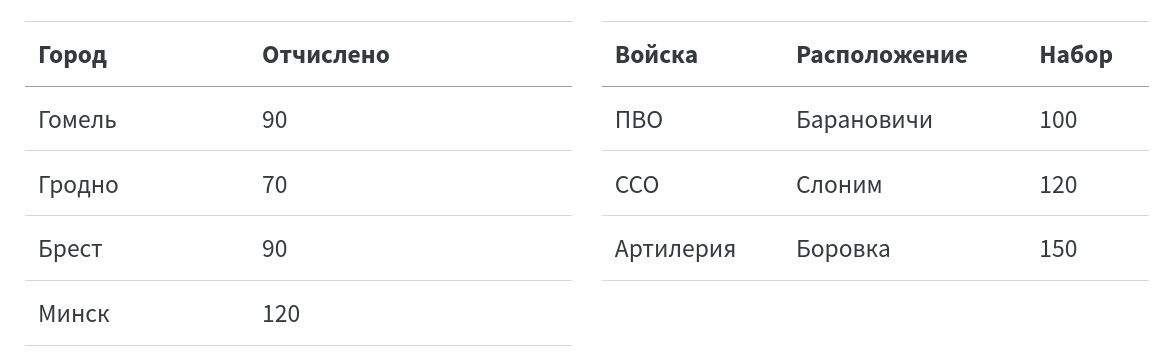
Справочно приводится таблица расстояний
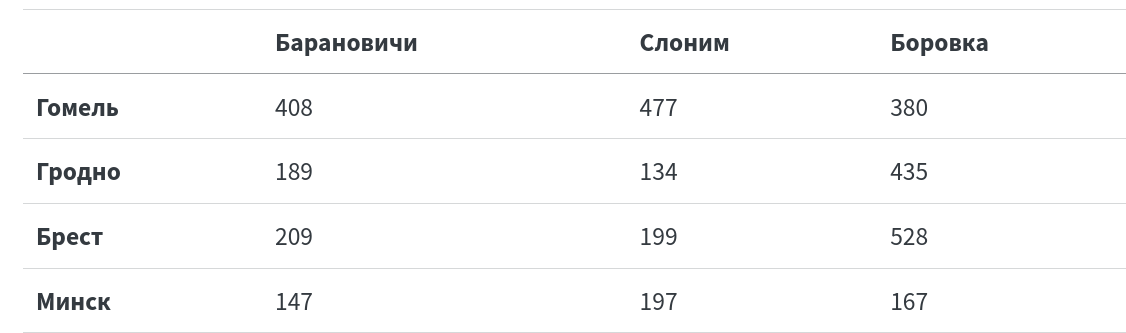

In [16]:
# Запасы (города: Гомель, Гродно, Брест, Минск)
supply = [90, 70, 90, 120]

# Потребности (части: Барановичи, Слоним, Боровка)
demand = [100, 120, 150]

# Матрица стоимостей
costs = [
    [408, 477, 380], # Гомель
    [189, 134, 435], # Гродно
    [209, 199, 528], # Брест
    [147, 197, 167]  # Минск
]

c = np.array(costs).flatten()

A_eq = []
b_eq = []

In [17]:
# Ограничения по запасам (отчисленным из городов)
for i in range(4):
    row = np.zeros(12)
    row[i*3 : (i+1)*3] = 1
    A_eq.append(row)
    b_eq.append(supply[i])

# Ограничения по потребностям (набору в части)
for j in range(3):
    row = np.zeros(12)
    for i in range(4):
        row[i*3 + j] = 1
    A_eq.append(row)
    b_eq.append(demand[j])

bounds = [(0, None) for _ in range(12)]

In [18]:
res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

if res.success:
    print(f"\nМинимальная суммарная стоимость (расстояние): {res.fun:.0f}\n")
    solution_matrix = np.array(res.x).reshape(4, 3)

    cities = ["Гомель", "Гродно", "Брест", "Минск"]
    bases = ["ПВО (Барановичи)", "ССО (Слоним)", "Артилерия (Боровка)"]

    for i in range(4):
        for j in range(3):
            val = round(solution_matrix[i][j])
            if val > 0:
                print(f"Из г. {cities[i]:<7} в {bases[j]:<20} -> отправлено {val} чел. (расстояние: {costs[i][j]})")
else:
    print("Решение не найдено.")


Минимальная суммарная стоимость (расстояние): 80730

Из г. Гомель  в Артилерия (Боровка)  -> отправлено 90 чел. (расстояние: 380)
Из г. Гродно  в ССО (Слоним)         -> отправлено 70 чел. (расстояние: 134)
Из г. Брест   в ПВО (Барановичи)     -> отправлено 40 чел. (расстояние: 209)
Из г. Брест   в ССО (Слоним)         -> отправлено 50 чел. (расстояние: 199)
Из г. Минск   в ПВО (Барановичи)     -> отправлено 60 чел. (расстояние: 147)
Из г. Минск   в Артилерия (Боровка)  -> отправлено 60 чел. (расстояние: 167)


Упражнение 25.2 (Распределение на практику) В конце обучения факультет распределяет студентов для прохождения практики. Информация о студентах и заказчиках приведена в таблицах ниже. Специальности приведены в порядке приоритета предприятия. Если организация в которую распределяется студент не соответствует специальности, то растут издержки. Постройте схему распределения минимизирующую издержки.
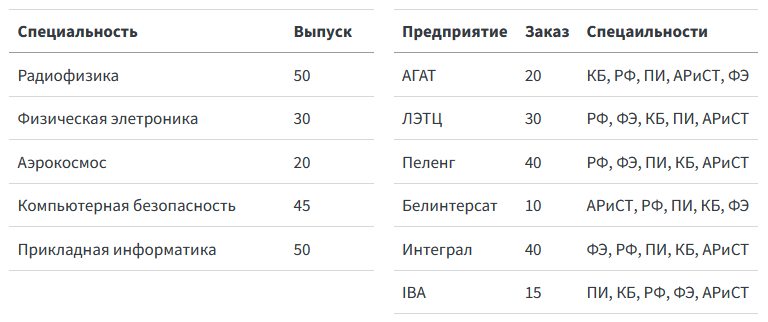

In [19]:
# Выпуск по специальностям (РФ, ФЭ, АРиСТ, КБ, ПИ)
supply = [50, 30, 20, 45, 50]

# Заказы предприятий (АГАТ, ЛЭТЦ, Пеленг, Белинтерсат, Интеграл, IBA)
demand = [20, 30, 40, 10, 40, 15]

# Стоимость в у.е.
costs = [
    [2, 1, 1, 2, 2, 3], # РФ
    [5, 2, 2, 5, 1, 4], # ФЭ
    [4, 5, 5, 1, 5, 5], # АРиСТ
    [1, 3, 4, 4, 4, 2], # КБ
    [3, 4, 3, 3, 3, 1]  # ПИ
]

c = np.array(costs).flatten()

In [20]:
# для запасов (выпуска), знак <=
A_ub = []
b_ub = []

for i in range(5):
    row = np.zeros(30)
    row[i*6 : (i+1)*6] = 1 # 6 предприятий для каждой специальности
    A_ub.append(row)
    b_ub.append(supply[i])

A_eq = []
b_eq = []

for j in range(6):
    row = np.zeros(30)
    for i in range(5):
        row[i*6 + j] = 1
    A_eq.append(row)
    b_eq.append(demand[j])

# распределить меньше 0 человек нельзя
bounds = [(0, None) for _ in range(30)]

res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

In [21]:
print("=== Оптимальное распределение студентов ===")

if res.success:
    print(f"\nМинимальные суммарные издержки: {res.fun:.0f}\n")

    solution_matrix = np.array(res.x).reshape(5, 6)

    specialties = ["Радиофизика", "Физ. электроника", "Аэрокосмос", "Комп. безопасность", "Прикл. информатика"]
    companies = ["АГАТ", "ЛЭТЦ", "Пеленг", "Белинтерсат", "Интеграл", "IBA"]

    total_assigned = np.zeros(5)

    # Печатаем распределение
    for i in range(5):
        print(f"[{specialties[i]}] (Выпуск: {supply[i]}):")
        for j in range(6):
            val = round(solution_matrix[i][j])
            if val > 0:
                print(f"  -> {companies[j]:<12}: направлено {val} студ. (Приоритет: {costs[i][j]})")
                total_assigned[i] += val

        # Считаем нераспределенных
        unassigned = supply[i] - total_assigned[i]
        if unassigned > 0:
            print(f"  * Не распределено: {int(unassigned)} студ.")
        print("-" * 40)

=== Оптимальное распределение студентов ===

Минимальные суммарные издержки: 215

[Радиофизика] (Выпуск: 50):
  -> ЛЭТЦ        : направлено 10 студ. (Приоритет: 1)
  -> Пеленг      : направлено 40 студ. (Приоритет: 1)
----------------------------------------
[Физ. электроника] (Выпуск: 30):
  -> Интеграл    : направлено 30 студ. (Приоритет: 1)
----------------------------------------
[Аэрокосмос] (Выпуск: 20):
  -> Белинтерсат : направлено 10 студ. (Приоритет: 1)
  * Не распределено: 10 студ.
----------------------------------------
[Комп. безопасность] (Выпуск: 45):
  -> АГАТ        : направлено 20 студ. (Приоритет: 1)
  -> ЛЭТЦ        : направлено 20 студ. (Приоритет: 3)
  * Не распределено: 5 студ.
----------------------------------------
[Прикл. информатика] (Выпуск: 50):
  -> Интеграл    : направлено 10 студ. (Приоритет: 3)
  -> IBA         : направлено 15 студ. (Приоритет: 1)
  * Не распределено: 25 студ.
----------------------------------------


Упражнение 25.3 (Задача Янукович) При составлении плана идеологическо-воспитательной работы возникла следующая задача. Назначить ответственными за мероприятия (Комната, Мистер, Капустник, Дни РФиКТ, Рафждество) одну из 4 студенческих организаций: студ. совет, творческое объединение ArtWave, БРСМ, профком. Основываясь на собственном опыте Татьяна Петровна пришла к следующей экспертной оценке возможностей организаций (больше лучше). Составьте оптимальный план работы
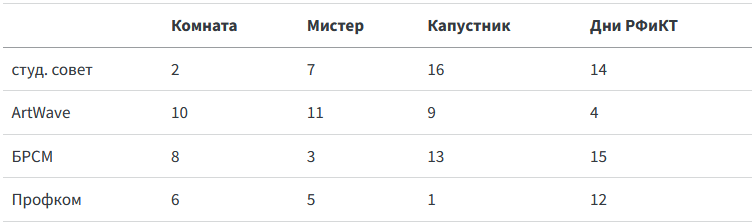

In [22]:
profits = [
    [2, 7, 16, 14],  # Студ. совет
    [10, 11, 9, 4],  # ArtWave
    [8, 3, 13, 15],  # БРСМ
    [6, 5, 1, 12]    # Профком
]

c = -np.array(profits).flatten()

A_eq = []
b_eq = []

# Ограничения по организациям
for i in range(4):
    row = np.zeros(16)
    row[i*4 : (i+1)*4] = 1
    A_eq.append(row)
    b_eq.append(1)

# Ограничения по мероприятиям
for j in range(4):
    row = np.zeros(16)
    for i in range(4):
        row[i*4 + j] = 1
    A_eq.append(row)
    b_eq.append(1)

bounds = [(0, 1) for _ in range(16)]

res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

print("=== Оптимальный план распределения мероприятий ===")
print(f"\nМаксимальная суммарная оценка: {-res.fun:.0f}\n")

solution_matrix = np.array(res.x).reshape(4, 4)

orgs = ["Студ. совет", "ArtWave", "БРСМ", "Профком"]
events = ["Комната", "Мистер", "Капустник", "Дни РФиКТ"]

for i in range(4):
    for j in range(4):
        if round(solution_matrix[i][j]) == 1:
            print(f"[{orgs[i]:<12}] назначается на -> {events[j]:<10} (Оценка: {profits[i][j]})")

=== Оптимальный план распределения мероприятий ===

Максимальная суммарная оценка: 48

[Студ. совет ] назначается на -> Капустник  (Оценка: 16)
[ArtWave     ] назначается на -> Мистер     (Оценка: 11)
[БРСМ        ] назначается на -> Дни РФиКТ  (Оценка: 15)
[Профком     ] назначается на -> Комната    (Оценка: 6)


Упражнение 25.4 (Задача Людчика) В таблице приведены результаты анкетирования студентов записавшихся в студотряд на лето. В таблице приводится запрос от организаций.

В таблице приводится анкета, значениями являются приоритеты, где 1 наивысший.

Требуется распределить студентов по отрядом максимально учитывая их пожелания. Сравните производительность и объясните различие методов

In [23]:
import pandas as pd
import time
from scipy.optimize import linprog, linear_sum_assignment

org_df = pd.read_csv('organizations.csv')
q_df = pd.read_csv('questionnaire.csv')

# 2. Подготовка (расширение) матрицы стоимостей
# Нам нужно продублировать столбцы организаций пропорционально числу их вакансий
expanded_columns = []
vacancy_labels = [] # Сохраним названия организаций для каждого слота

for index, row in org_df.iterrows():
    org_name = row.iloc[0]      # Название организации
    vacancies = row.iloc[1]     # Количество мест

    # Если организация есть в анкете, дублируем её столбец
    if org_name in q_df.columns:
        for _ in range(vacancies):
            expanded_columns.append(q_df[org_name].values)
            vacancy_labels.append(org_name)

# Транспонируем список списков, чтобы получить матрицу:
# Строки - студенты, Столбцы - конкретные вакантные места
cost_matrix = np.array(expanded_columns).T
num_students = cost_matrix.shape[0]
num_vacancies = cost_matrix.shape[1]

print(f"Количество студентов: {num_students}")
print(f"Общее количество рабочих мест: {num_vacancies}")
print(f"Размерность итоговой матрицы: {cost_matrix.shape}")

Количество студентов: 2214
Общее количество рабочих мест: 2214
Размерность итоговой матрицы: (2214, 2214)


In [26]:
# =======================================================
# МЕТОД 1: Специализированный (Венгерский алгоритм)
# =======================================================
start_time_lsap = time.time()

# linear_sum_assignment принимает матрицу издержек напрямую
row_ind, col_ind = linear_sum_assignment(cost_matrix)

time_lsap = time.time() - start_time_lsap
cost_lsap = cost_matrix[row_ind, col_ind].sum()

print("=== Метод 1: linear_sum_assignment (Венгерский алгоритм) ===")
print(f"Минимальная сумма приоритетов: {cost_lsap}")
print(f"Время выполнения: {time_lsap:.6f} сек.\n")


# =======================================================
# МЕТОД 2: Универсальный (Линейное программирование)
# =======================================================
# Подготовка огромной матрицы ограничений для linprog
# Количество переменных = num_students * num_vacancies
N = num_students
c = cost_matrix.flatten()

# Строим матрицу A_eq и вектор b_eq
A_eq = np.zeros((2 * N, N * N))
b_eq = np.ones(2 * N)

# Ограничения: 1 студент = 1 рабочее место
for i in range(N):
    A_eq[i, i*N : (i+1)*N] = 1

# Ограничения: 1 рабочее место = 1 студент
for j in range(N):
    A_eq[N + j, j::N] = 1

bounds = [(0, 1) for _ in range(N * N)]

start_time_linprog = time.time()

res_linprog = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

time_linprog = time.time() - start_time_linprog

print("=== Метод 2: linprog (Симплекс-метод / Highs) ===")
if res_linprog.success:
    print(f"Минимальная сумма приоритетов: {res_linprog.fun:.0f}")
    print(f"Время выполнения: {time_linprog:.6f} сек.")
else:
    print("linprog не смог найти решение.")

print("\n=== Сравнение производительности ===")
speedup = time_linprog / time_lsap if time_lsap > 0 else float('inf')
print(f"Венгерский алгоритм быстрее в ~{speedup:.1f} раз(а)")

=== Метод 1: linear_sum_assignment (Венгерский алгоритм) ===
Минимальная сумма приоритетов: 3691
Время выполнения: 0.293538 сек.

Подготовка данных для linprog (разреженные матрицы)...
Запуск linprog... (ВНИМАНИЕ: для 2000+ переменных это может занять несколько минут!)

=== Метод 2: linprog (Симплекс-метод / Highs) ===
Минимальная сумма приоритетов: 3691
Время выполнения: 170.293405 сек.

=== Сравнение производительности ===
Венгерский алгоритм (linear_sum_assignment) быстрее в ~580.1 раз(а)
